#Object Detection using YOLOV8

##Generate your kaggle token from profile and upload the json file in the cell below

In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"laibaafreen","key":"fcfb3e347a0c91cf3b51c14d3be9182a"}'}

##Create a directory for kaggle datasets

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##Download the required dataset

In [3]:
!kaggle datasets download -d alincijov/self-driving-cars
!unzip self-driving-cars.zip -d self-driving-cars/

Streaming output truncated to the last 5000 lines.
  inflating: self-driving-cars/images/1479502279230178611.jpg  
  inflating: self-driving-cars/images/1479502279730506173.jpg  
  inflating: self-driving-cars/images/1479502280230536426.jpg  
  inflating: self-driving-cars/images/1479502280730839737.jpg  
  inflating: self-driving-cars/images/1479502281729824146.jpg  
  inflating: self-driving-cars/images/1479502282229848985.jpg  
  inflating: self-driving-cars/images/1479502282730102580.jpg  
  inflating: self-driving-cars/images/1479502283731724690.jpg  
  inflating: self-driving-cars/images/1479502284232432719.jpg  
  inflating: self-driving-cars/images/1479502285221790200.jpg  
  inflating: self-driving-cars/images/1479502285730163274.jpg  
  inflating: self-driving-cars/images/1479502286231098378.jpg  
  inflating: self-driving-cars/images/1479502287230097438.jpg  
  inflating: self-driving-cars/images/1479502287730246905.jpg  
  inflating: self-driving-cars/images/147950228823126

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='#f79a05'>💡 Inspiration:</font></h3>
    
**Purpose**: to object detection in images by using **YOLOv8**.

**Object detection** is a computer technology related to computer vision and image processing that deals with detecting instances of semantic objects of a certain class (such as humans, buildings, or cars) in digital images and videos.
When it comes to object detection, popular detection frameworks are

* YOLO
* SSD
* Faster R-CNN


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> What is YOLO exactly?</p>

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='black'>What is YOLO exactly?</font></h3>
    
**YOLO** (You Only Look Once) is a method / way to do object detection. It is the algorithm /strategy behind how the code is going to detect objects in the image.

Earlier detection frameworks, looked at different parts of the image multiple times at different scales and repurposed image classification technique to detect objects. This approach is slow and inefficient.

YOLO takes entirely different approach. It looks at the entire image only once and goes through the network once and detects objects. Hence the name. It is very fast. That’s the reason it has got so popular.

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Import Libraries</p>

In [4]:
import numpy as np
import pandas as pd
import cv2

from sklearn.utils import shuffle
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

### <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Load data</p>

In [5]:
df = pd.read_csv('self-driving-cars/labels_train.csv')
df = shuffle(df)
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
67529,1479499149516770617.jpg,149,158,142,158,1
65088,1479498737489138884.jpg,120,147,145,162,1
101848,1479503327287752354.jpg,134,159,139,158,1
27720,1478732804973551360.jpg,95,106,144,153,1
29556,1478732954652069815.jpg,85,134,142,169,1


<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">
    
 * This dataset is mostly a practice and training aspect for the subject of YOLO. The data is labeled with 5 classes.
 * classic_id labels: 'car', 'truck', 'pedestrian', 'bicyclist', 'light'

In [6]:
classes = df.class_id.unique()
print(classes)

[1 5 3 2 4]


In [7]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Show some labeled images</p>

In [8]:
# Get path images and boxes (x,y) for each class_id
boxes = {}
images = {}

base_path = 'self-driving-cars/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

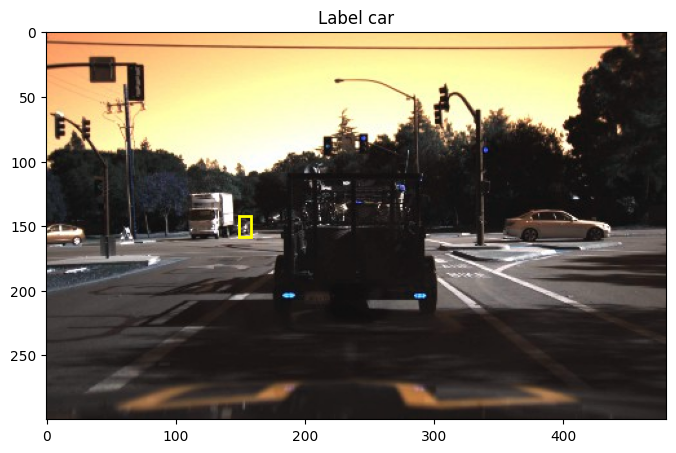

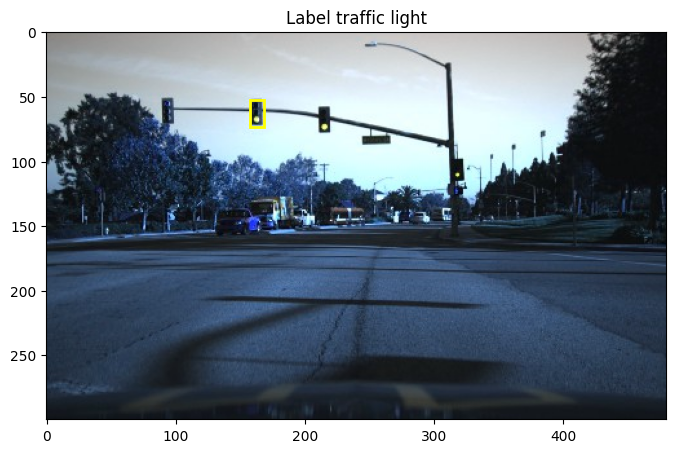

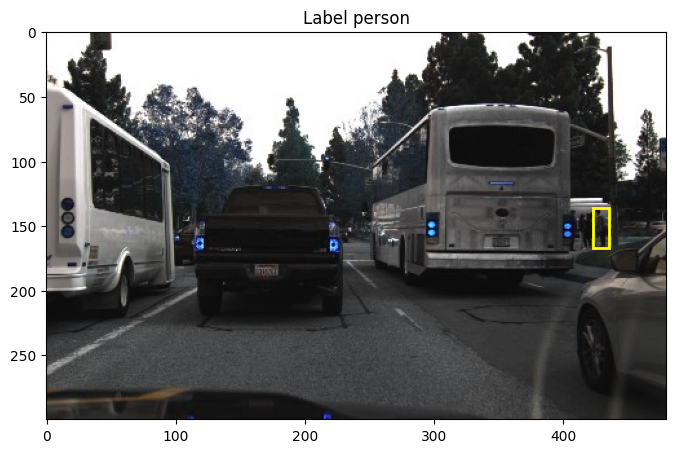

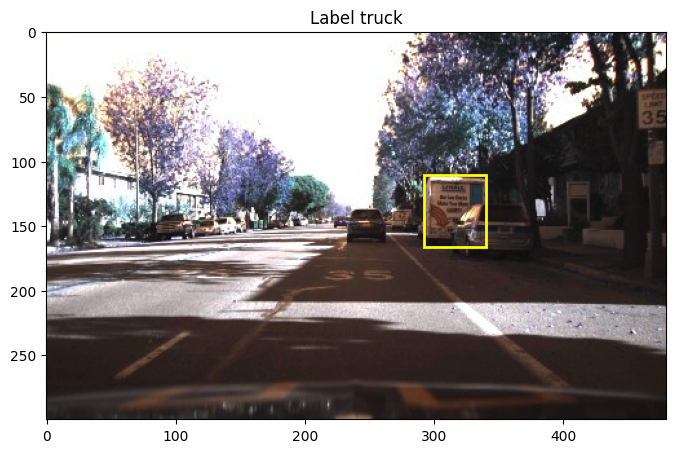

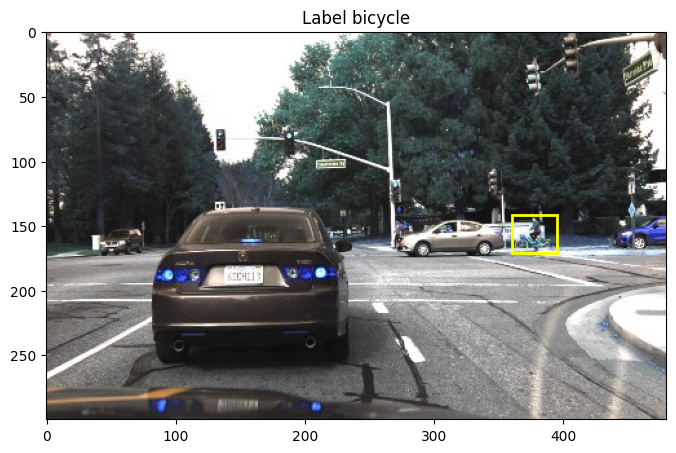

In [9]:
for i in classes:

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title("Label " + labels[i])
    plt.imshow(images[i])
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Model</p>

In [10]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.1 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display
import os
import pathlib

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
model = YOLO("yolov8m.pt")

In [13]:
results=model.predict(source="self-driving-cars/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /content/self-driving-cars/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 1145.1ms
Speed: 13.4ms preprocess, 1145.1ms inference, 32.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


In [14]:
result = results[0]
box = result.boxes[0]

In [15]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs  # Class probabilities for classification outputs

In [16]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.6882781982422, 148.7809295654297, 162.10047912597656]
Probability: 0.7161701321601868


In [17]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


In [18]:
results1 = model.predict(source="self-driving-cars/images/1478020211690815798.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /content/self-driving-cars/images/1478020211690815798.jpg: 416x640 4 cars, 3 traffic lights, 1406.7ms
Speed: 6.0ms preprocess, 1406.7ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


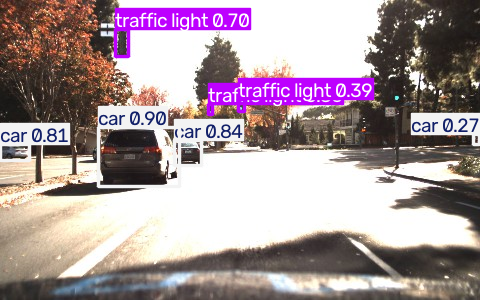

In [19]:
# Plotting results
plot = results1[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

##Exercise (Object-Detection Visualization)
**Using the concepts from the notebook—loading annotations from a CSV, reading images, and drawing bounding boxes—write a short script that:**

1. Loads the labels_train.csv into a pandas DataFrame.

2. Randomly selects one image filename from the DataFrame.

3. Reads its image file from self-driving-cars/images/.

4. Filters the DataFrame to get all bounding-box annotations for that image (columns: xmin, ymin, xmax, ymax and class).

5. Draws each box (and class label) onto the image using PIL.ImageDraw.

6. Displays the resulting annotated image.



Loaded 132406 annotations
Columns: ['frame', 'xmin', 'xmax', 'ymin', 'ymax', 'class_id']
First 5 rows:
                           frame  xmin  xmax  ymin  ymax  class_id
40600   1478897155738276363.jpg    49    83   150   176         2
28297   1478732857733591551.jpg   377   398   138   155         1
15291   1478731993493681049.jpg   227   234   120   130         5
42107   1478897274566985716.jpg   332   352   147   172         1
128040  1479505836968762723.jpg   229   238   143   150         1

Total unique images: 18000
Selected image: 1479504071351374087.jpg
Image shape: (300, 480, 3)

Found 6 annotations for this image:
  - car: x=(128-147), y=(146-162)
  - car: x=(142-159), y=(144-159)
  - person: x=(203-214), y=(128-168)
  - car: x=(236-244), y=(143-155)
  - car: x=(187-197), y=(144-154)
  - car: x=(218-241), y=(141-161)


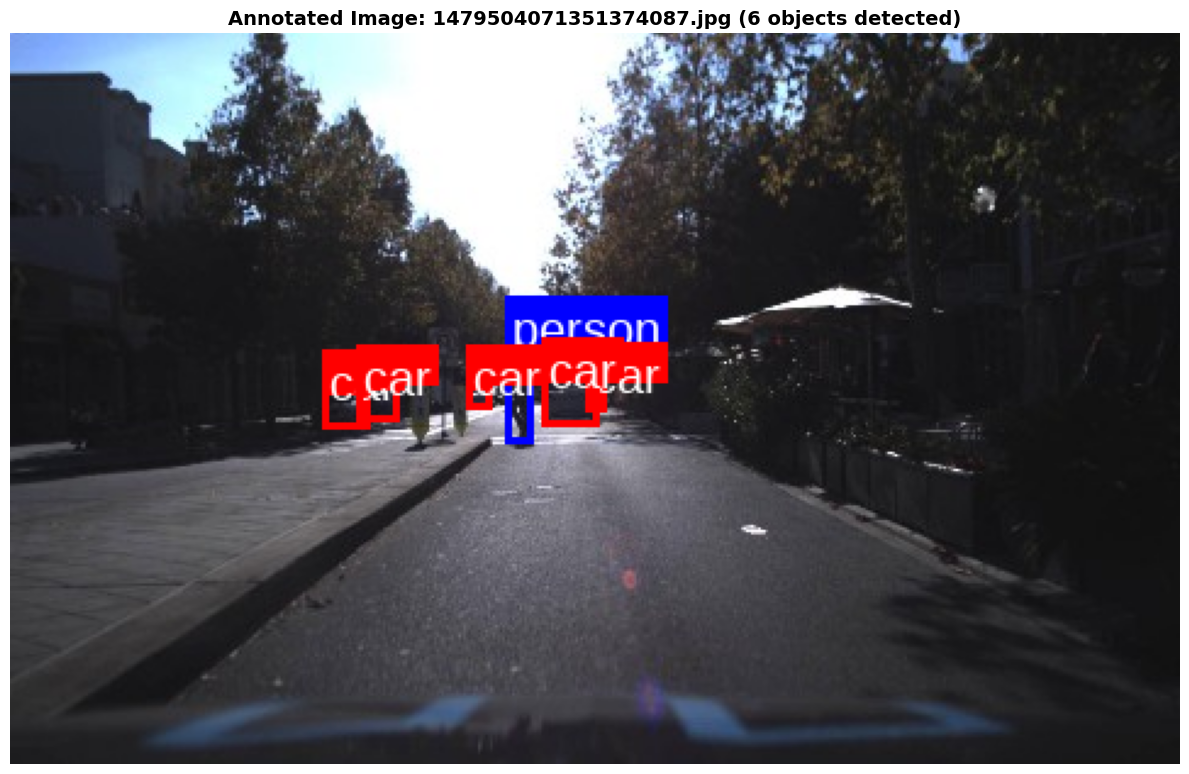


Displaying with PIL's show method...

SUMMARY
✓ Loaded annotations CSV with 132406 rows
✓ Randomly selected image: 1479504071351374087.jpg
✓ Found 6 objects in the image:
    • car: (128, 146) → (147, 162)
    • car: (142, 144) → (159, 159)
    • person: (203, 128) → (214, 168)
    • car: (236, 143) → (244, 155)
    • car: (187, 144) → (197, 154)
    • car: (218, 141) → (241, 161)
✓ Drew 6 bounding boxes with labels
✓ Displayed the annotated image


In [21]:
# ============================================================
# EXERCISE: Object Detection Visualization
# ============================================================

# Import required libraries
import pandas as pd
import cv2
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

# ---------- STEP 1: Load the labels_train.csv into a pandas DataFrame ----------
# The CSV contains image filenames and bounding box annotations
df = pd.read_csv('self-driving-cars/labels_train.csv')
df = shuffle(df, random_state=42)  # Shuffle with fixed random seed for reproducibility

print(f"Loaded {len(df)} annotations")
print(f"Columns: {df.columns.tolist()}")
print("First 5 rows:\n", df.head())

# ---------- STEP 2: Randomly select one image filename from the DataFrame ----------
# Get unique image filenames and pick one randomly
unique_images = df['frame'].unique()
print(f"\nTotal unique images: {len(unique_images)}")

# Randomly select an image
random_image_filename = random.choice(unique_images)
print(f"Selected image: {random_image_filename}")

# ---------- STEP 3: Read its image file from self-driving-cars/images/ ----------
# Construct the full image path
image_path = f'self-driving-cars/images/{random_image_filename}'

# Read the image using OpenCV
image_cv = cv2.imread(image_path)

# Check if image was loaded successfully
if image_cv is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# Convert BGR (OpenCV default) to RGB for display
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

# Convert to PIL Image for easier drawing
pil_image = Image.fromarray(image_rgb)
print(f"Image shape: {image_rgb.shape}")

# ---------- STEP 4: Filter the DataFrame for all annotations for this image ----------
# Get all annotations for the selected image
image_annotations = df[df['frame'] == random_image_filename].copy()

# Class mapping (from the original notebook)
class_labels = {1: 'car', 2: 'truck', 3: 'person', 4: 'bicycle', 5: 'traffic light'}

print(f"\nFound {len(image_annotations)} annotations for this image:")

# Print each annotation with class name
for idx, row in image_annotations.iterrows():
    class_name = class_labels.get(row['class_id'], f"Class_{row['class_id']}")
    print(f"  - {class_name}: x=({row['xmin']}-{row['xmax']}), y=({row['ymin']}-{row['ymax']})")

# ---------- STEP 5: Draw each box and class label using PIL.ImageDraw ----------
# Create a drawing context
draw = ImageDraw.Draw(pil_image)

# Colors for different classes (RGB format)
class_colors = {
    1: (255, 0, 0),      # car - Red
    2: (0, 255, 0),      # truck - Green
    3: (0, 0, 255),      # person - Blue
    4: (255, 255, 0),    # bicycle - Cyan
    5: (255, 0, 255)     # traffic light - Magenta
}

# Try to load a font for better text display
try:
    # Use default font with size 20
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf", 20)
except:
    font = ImageFont.load_default()

# Draw each bounding box
for idx, row in image_annotations.iterrows():
    # Get bounding box coordinates
    xmin = int(row['xmin'])
    ymin = int(row['ymin'])
    xmax = int(row['xmax'])
    ymax = int(row['ymax'])

    # Get class information
    class_id = row['class_id']
    class_name = class_labels.get(class_id, f"Class_{class_id}")
    color = class_colors.get(class_id, (255, 255, 255))  # Default: white

    # ---- Draw the bounding box ----
    # Draw rectangle with 3px border
    draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)

    # ---- Draw the class label ----
    # Create text with class name
    label_text = class_name

    # Calculate text size (for background rectangle)
    # Using textbbox to get the text dimensions
    text_bbox = draw.textbbox((xmin, ymin), label_text, font=font)
    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]

    # Draw background rectangle for text (for better readability)
    # Position the text background slightly above the box or inside if there's space
    if ymin - text_height - 5 > 0:
        # Put text above the box
        text_bg = [xmin, ymin - text_height - 5,
                   xmin + text_width + 5, ymin]
    else:
        # Put text inside the box (top-left)
        text_bg = [xmin, ymin,
                   xmin + text_width + 5, ymin + text_height + 5]

    # Draw semi-transparent background (simulated with solid color)
    draw.rectangle(text_bg, fill=color)

    # Draw text in white on the background
    draw.text((xmin + 3, text_bg[1] + 2),
              label_text,
              fill=(255, 255, 255),  # White text
              font=font)

# ---------- STEP 6: Display the resulting annotated image ----------
# Display using matplotlib for a clean view
plt.figure(figsize=(12, 8))
plt.imshow(pil_image)
plt.axis('off')  # Hide axes
plt.title(f'Annotated Image: {random_image_filename} ({len(image_annotations)} objects detected)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Also display using PIL's built-in show method
print("\nDisplaying with PIL's show method...")
pil_image.show()  # This opens the image in your default image viewer

# ---------- EXTRA: Print summary of what we've done ----------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✓ Loaded annotations CSV with {len(df)} rows")
print(f"✓ Randomly selected image: {random_image_filename}")
print(f"✓ Found {len(image_annotations)} objects in the image:")
for idx, row in image_annotations.iterrows():
    class_name = class_labels.get(row['class_id'], f"Class_{row['class_id']}")
    print(f"    • {class_name}: ({row['xmin']}, {row['ymin']}) → ({row['xmax']}, {row['ymax']})")
print(f"✓ Drew {len(image_annotations)} bounding boxes with labels")
print("✓ Displayed the annotated image")
print("="*60)